# Lexical dispersion

In [4]:
import polars as pl
import polars_corpus as plc

import matplotlib.pyplot as plt

In [10]:
pl.Config.set_tbl_rows(20)

polars.config.Config

In [6]:
brown = pl.read_parquet("brown.parquet")

- `range` : number of files the word occurs in
- `range%` : the range as a percentage of the files in the corpus
- `sd` : standard deviation of the per-file frequencies $Y_i$:
  $$S=\sqrt{\frac{1}{k}\sum_{i=1}^k(Y_i-\bar Y)^2}$$
- `cv` : coefficient of variation, sd over the mean
   $$CV=\frac{S}{\bar Y}$$
- `cv%` : the coefficient of variation as a percentage
   $$CV\%=\frac{CV}{\sqrt{\textrm{no.\ of corpus parts}}}$$
- `d` : Julliand's $D$:
  $$D=1-\sqrt{\frac{\frac{1}{k-1}\sum_{i=1}^k(Y_i-\bar Y)^2}{k\bar Y^2}}$$

  $$D=1-\sqrt{\frac{\frac{1}{k-1}\sum_i=1^k(Y_i-\bar Y)^2}{k\bar Y^2}$$


- `da` : Burch's DA, from the average difference between pairs of files
- `dp` : Gries's DP, how far the word's spread over the files falls from the corpus's own

In [29]:
disp = plc.dispersion(brown, "token", method=['range','range%','sd','cv','cv%','d','da','dp'], min_freq=200)

In [53]:
disp.sort(by='DA', descending=True).head(100).tail()

token,freq,range,range%,sd,cv,cv%,D,DA,DP
str,u32,u32,f64,f64,f64,f64,f64,f64,f64
"""being""",691,332,66.4,0.000636,1.064893,106.489328,0.952329,0.445036,0.420003
"""too""",801,334,66.8,0.000715,1.043335,104.333484,0.953294,0.443558,0.4229
"""still""",731,334,66.8,0.000685,1.089647,108.964714,0.951221,0.442217,0.419202
"""another""",573,318,63.6,0.000533,1.078891,107.889116,0.951702,0.44111,0.408137
"""can""",1738,400,80.0,0.001733,1.147732,114.773185,0.94862,0.440367,0.409075


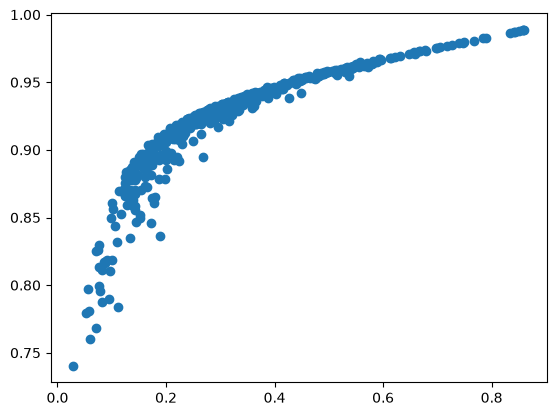

In [31]:
plt.scatter(disp['DA'], disp['D'])

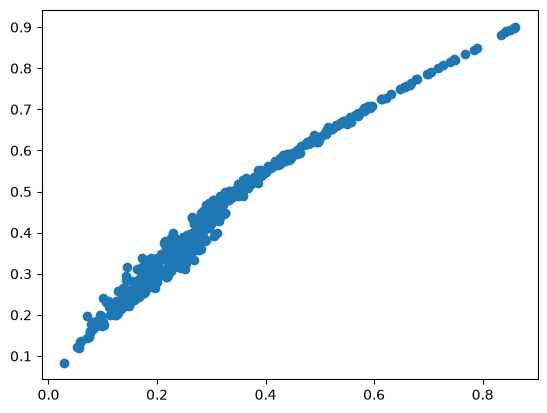

In [32]:
plt.scatter(disp['DA'], 1-disp['DP'])

# 

<Axes: xlabel='index'>

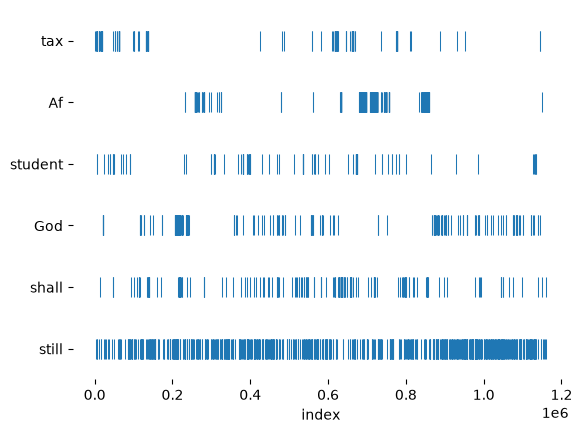

In [54]:
plc.barcode_plot(brown, "token", ['tax','Af','student','God','shall','still'])


([], [])

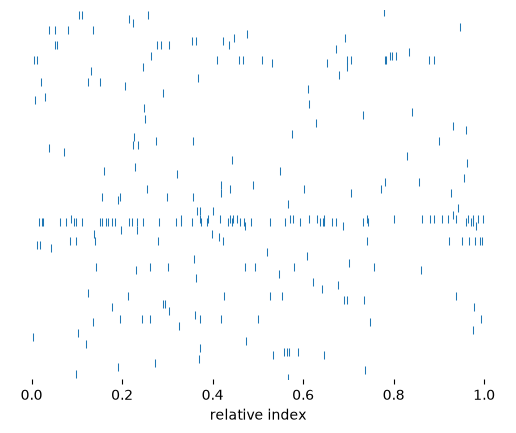

In [48]:
plc.dispersion_plot(brown, "token", 'shall', relative=True, size=30)
plt.yticks([])



<Axes: xlabel='index'>

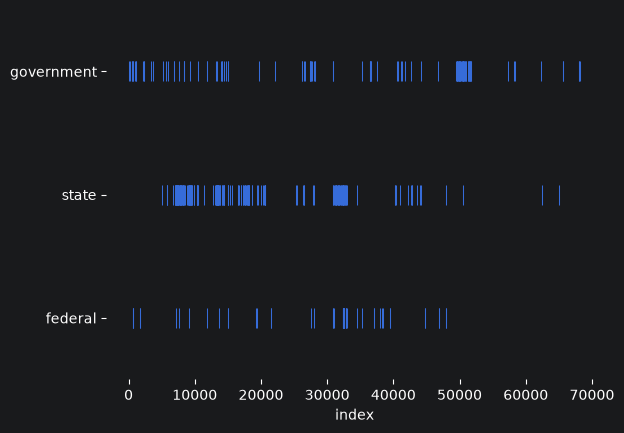

In [13]:
plc.barcode_plot(brown.filter(pl.col('category')=='government'),
                 pl.col("token").str.to_lowercase(),
                 ['government','state','federal',]
                 )
